In [1]:
"""
Basic Python Lebwohl-Lasher code.  Based on the paper 
P.A. Lebwohl and G. Lasher, Phys. Rev. A, 6, 426-429 (1972).
This version in 2D.

Run at the command line by typing:

python LebwohlLasher.py <ITERATIONS> <SIZE> <TEMPERATURE> <PLOTFLAG>

where:
  ITERATIONS = number of Monte Carlo steps, where 1MCS is when each cell
      has attempted a change once on average (i.e. SIZE*SIZE attempts)
  SIZE = side length of square lattice
  TEMPERATURE = reduced temperature in range 0.0 - 2.0.
  PLOTFLAG = 0 for no plot, 1 for energy plot and 2 for angle plot.
  
The initial configuration is set at random. The boundaries
are periodic throughout the simulation.  During the
time-stepping, an array containing two domains is used; these
domains alternate between old data and new data.

SH 16-Oct-23
"""

'\nBasic Python Lebwohl-Lasher code.  Based on the paper \nP.A. Lebwohl and G. Lasher, Phys. Rev. A, 6, 426-429 (1972).\nThis version in 2D.\n\nRun at the command line by typing:\n\npython LebwohlLasher.py <ITERATIONS> <SIZE> <TEMPERATURE> <PLOTFLAG>\n\nwhere:\n  ITERATIONS = number of Monte Carlo steps, where 1MCS is when each cell\n      has attempted a change once on average (i.e. SIZE*SIZE attempts)\n  SIZE = side length of square lattice\n  TEMPERATURE = reduced temperature in range 0.0 - 2.0.\n  PLOTFLAG = 0 for no plot, 1 for energy plot and 2 for angle plot.\n\nThe initial configuration is set at random. The boundaries\nare periodic throughout the simulation.  During the\ntime-stepping, an array containing two domains is used; these\ndomains alternate between old data and new data.\n\nSH 16-Oct-23\n'

In [2]:
import sys
import time
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


In [3]:
def initdat(nmax):# 1號
    """
    #依照晶格大小產生同等數量晶體，並隨機賦予角度(所以乘上2pi(0~360度)，接著會在從角度去反推位置(平面座標)，找出向量的概念)
      nmax (int) = size of lattice to create (nmax,nmax).
    Description:
      Function to create and initialise the main data array that holds
      the lattice.  Will return a square lattice (size nmax x nmax)
	  initialised with random orientations in the range [0,2pi].
	Returns:
	  arr (float(nmax,nmax)) = array to hold lattice.
    """
    arr = np.random.random_sample((nmax,nmax))*2.0*np.pi  
    return arr

In [4]:
arr = initdat(50)
type(arr)
print(arr.shape)
arr[0] # arr 第一個值

(50, 50)


array([3.97967326, 0.8854959 , 3.41647478, 2.39515561, 6.13575499,
       1.03507861, 4.28292696, 4.64007403, 0.68443792, 3.69490894,
       4.98135504, 3.57715582, 1.19380536, 3.89586037, 4.76929533,
       3.21593144, 4.24602522, 5.44023282, 3.59745488, 1.41135765,
       0.66365167, 5.1054772 , 4.77473998, 6.11020765, 1.0947162 ,
       0.45311742, 1.43242789, 0.7645655 , 1.1478925 , 4.35411093,
       1.41953267, 0.53770967, 3.46943416, 3.50942206, 4.1329767 ,
       0.99697403, 2.54928623, 1.34042781, 0.90225841, 3.21078859,
       0.71185186, 3.99552055, 5.20890395, 1.41044971, 3.53456115,
       0.30232962, 0.95054216, 6.15433959, 4.56349574, 1.61051589])

In [ ]:
def plotdat(arr,pflag,nmax): # plot的設定 2號
    """
    Arguments:
	  arr (float(nmax,nmax)) = array that contains lattice data;
	  pflag (int) = parameter to control plotting;
      nmax (int) = side length of square lattice.
    Description:
      Function to make a pretty plot of the data array.  Makes use of the
      quiver plot style in matplotlib.  Use pflag to control style:
        pflag = 0 for no plot (for scripted operation);
        pflag = 1 for energy plot;
        pflag = 2 for angles plot;
        pflag = 3 for black plot.
	  The angles plot uses a cyclic color map representing the range from
	  0 to pi.  The energy plot is normalised to the energy range of the
	  current frame.
	Returns:
      NULL
    """
    if pflag==0:
        return
    u = np.cos(arr) # x 座標
    v = np.sin(arr) # y 座標
    x = np.arange(nmax) # x 數量
    y = np.arange(nmax) # y數量
    cols = np.zeros((nmax,nmax)) #用來存每個分子的能量
    if pflag==1: # colour the arrows according to energy
        mpl.rc('image', cmap='rainbow')
        cols= energy_calculation(arr) # 這裡得到的是一個array, 包含所有分子的能量(nmax*nmax)
        #存完nmax * nmax個分子能量
        norm = plt.Normalize(cols.min(), cols.max())
    elif pflag==2: # colour the arrows according to angle
        mpl.rc('image', cmap='hsv')
        cols = arr%np.pi # 正規化，因為液晶分子有頭尾對稱性 所以圓和半圓範圍對應的值是等價的
        norm = plt.Normalize(vmin=0, vmax=np.pi) # 顏色範圍，最小值0,最大值np.pi(所以他正則化可以把範圍很好的縮小但不影響真實情況)
    else:
        mpl.rc('image', cmap='gist_gray')
        cols = np.zeros_like(arr) # 建立一個數量對等的全0陣列
        norm = plt.Normalize(vmin=0, vmax=1)
    quiveropts = dict(headlength=0,pivot='middle',headwidth=1,scale=1.1*nmax) # 分子的火財棒圖樣設定
    fig, ax = plt.subplots()
    q = ax.quiver(x, y, u, v, cols,norm=norm, **quiveropts) # col被當作顏色使用了
    ax.set_aspect('equal')
    plt.show()
    #plt.savefig(f'my_lattice_plot_{nmax}.png')

In [ ]:
def energy_calculation(arr):
    en = 0.0
    neighbors = {
        "up" : np.roll(arr, shift=1, axis=0),
        "down" : np.roll(arr, shift=-1, axis = 0),
        "right": np.roll(arr, shift=1,axis = 1),
        "left" :np.roll(arr, shift=-1, axis=1)
    }
    #取鄰居 前後左右
    angs = np.stack([arr - neighbors[x] for x in neighbors]) #array 減掉四個鄰居，得到角度 ndarray(4*nmax*nmax) 上下左右四個矩陣之間的角度
    #print(angs)
    #print(angs.shape)
    en = 0.5*(1.0 - 3.0*np.cos(angs)**2) # 計算四個角度矩陣全部能量
    total_en = np.sum(en, axis=0) # 把四個能量加在一起 = 分子的總能量 ( nmax*nmax )後面有一個all_energy function的加總是在算全部分子的總能量(namx*nmax)的值全部加一起
    return total_en

In [21]:
def savedat(arr,nsteps,Ts,runtime,ratio,energy,order,nmax):
    """
    Arguments:
	  arr (float(nmax,nmax)) = array that contains lattice data;
	  nsteps (int) = number of Monte Carlo steps (MCS) performed;
	  Ts (float) = reduced temperature (range 0 to 2);
	  ratio (float(nsteps)) = array of acceptance ratios per MCS;
	  energy (float(nsteps)) = array of reduced energies per MCS;
	  order (float(nsteps)) = array of order parameters per MCS;
      nmax (int) = side length of square lattice to simulated.
    Description: #存最終展示的txt的那個表的資料
      Function to save the energy, order and acceptance ratio
      per Monte Carlo step to text file.  Also saves run data in the
      header.  Filenames are generated automatically based on
      date and time at beginning of execution.
	Returns:
	  NULL
    """
    # Create filename based on current date and time.
    current_datetime = datetime.datetime.now().strftime("%a-%d-%b-%Y-at-%I-%M-%S%p")
    filename = "LL-Output-{:s}.txt".format(current_datetime)
    FileOut = open(filename,"w")
    # Write a header with run parameters
    print("#=====================================================",file=FileOut)
    print("# File created:        {:s}".format(current_datetime),file=FileOut)
    print("# Size of lattice:     {:d}x{:d}".format(nmax,nmax),file=FileOut)
    print("# Number of MC steps:  {:d}".format(nsteps),file=FileOut)
    print("# Reduced temperature: {:5.3f}".format(Ts),file=FileOut)
    print("# Run time (s):        {:8.6f}".format(runtime),file=FileOut)
    print("#=====================================================",file=FileOut)
    print("# MC step:  Ratio:     Energy:   Order:",file=FileOut)
    print("#=====================================================",file=FileOut)
    # Write the columns of data
    for i in range(nsteps+1):
        print("   {:05d}    {:6.4f} {:12.4f}  {:6.4f} ".format(i,ratio[i],energy[i],order[i]),file=FileOut)
    FileOut.close()

In [22]:
def one_energy(arr,ix,iy,nmax):
    """
    Arguments:
	  arr (float(nmax,nmax)) = array that contains lattice data;
	  ix (int) = x lattice coordinate of cell;
	  iy (int) = y lattice coordinate of cell;
      nmax (int) = side length of square lattice.
    Description:
      Function that computes the energy of a single cell of the
      lattice taking into account periodic boundaries.  Working with
      reduced energy (U/epsilon), equivalent to setting epsilon=1 in
      equation (1) in the project notes.
	Returns:
	  en (float) = reduced energy of cell.
    """
    en = 0.0
    ixp = (ix+1)%nmax # These are the coordinates
    ixm = (ix-1)%nmax # of the neighbours
    iyp = (iy+1)%nmax # with wraparound
    iym = (iy-1)%nmax # 四個鄰居
#
# Add together the 4 neighbour contributions
# to the energy
# 算角度先，然後再依照公式計算en，每個都算一遍 但這邊他有變換一下公式
    ang = arr[ix,iy]-arr[ixp,iy]
    en += 0.5*(1.0 - 3.0*np.cos(ang)**2)
    ang = arr[ix,iy]-arr[ixm,iy]
    en += 0.5*(1.0 - 3.0*np.cos(ang)**2)
    ang = arr[ix,iy]-arr[ix,iyp]
    en += 0.5*(1.0 - 3.0*np.cos(ang)**2)
    ang = arr[ix,iy]-arr[ix,iym]
    en += 0.5*(1.0 - 3.0*np.cos(ang)**2)
    return en
#這個return 的en 就是這個分子自己的能量

In [38]:
def all_energy(arr,nmax): #計算全部分子的總total energy
    """
    Arguments:
	  arr (float(nmax,nmax)) = array that contains lattice data;
      nmax (int) = side length of square lattice.
    Description:
      Function to compute the energy of the entire lattice. Output
      is in reduced units (U/epsilon).
	Returns:
	  enall (float) = reduced energy of lattice.
    """
    enall = np.sum(energy_calculation(arr)) # 這個function其實感覺可以不用
    return enall

In [39]:
np.eye(3,3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [40]:
Qab = np.zeros((3,3))
Qab

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [41]:
lab = np.vstack((np.cos(arr),np.sin(arr),np.zeros_like(arr))).reshape(3,50,50)
lab[0,0,0]

-0.6688908575990196

In [42]:
def get_order(arr,nmax):
    """
    Arguments:
	  arr (float(nmax,nmax)) = array that contains lattice data;
      nmax (int) = side length of square lattice.
    Description:
      Function to calculate the order parameter of a lattice
      using the Q tensor approach, as in equation (3) of the
      project notes.  Function returns S_lattice = max(eigenvalues(Q_ab)).
	Returns:
	  max(eigenvalues(Qab)) (float) = order parameter for lattice.
    """
    Qab = np.zeros((3,3))
    delta = np.eye(3,3) # 他是一個單位矩陣，因為有xyz三個所以是三
    #
    # Generate a 3D unit vector for each cell (i,j) and
    # put it in a (3,i,j) array.
    #
    lab = np.vstack((np.cos(arr),np.sin(arr),np.zeros_like(arr))).reshape(3,nmax,nmax) # x, y, z在這邊計算了
    # z 都設0所以只跑a,b 兩個
    #取第 $i,j$ 個分子的 $a$ 軸分量 乘以它的 $b$ 軸分量
    for a in range(3):
        for b in range(3):
            for i in range(nmax):
                for j in range(nmax):
                    Qab[a,b] += 3*lab[a,i,j]*lab[b,i,j] - delta[a,b]
    Qab = Qab/(2*nmax*nmax)
    eigenvalues,eigenvectors = np.linalg.eig(Qab)
    return eigenvalues.max() # 取最大eigenvalues 這個就是我們這次的S

In [43]:
def MC_step(arr,Ts,nmax): #一次 mc step 代表 轉動一個分子看全部會如何
    """
    Arguments:
	  arr (float(nmax,nmax)) = array that contains lattice data;
	  Ts (float) = reduced temperature (range 0 to 2);#溫度範圍0~2
      nmax (int) = side length of square lattice.
    Description:
      Function to perform one MC step, which consists of an average
      of 1 attempted change per lattice site.  Working with reduced
      temperature Ts = kT/epsilon.  Function returns the acceptance
      ratio for information.  This is the fraction of attempted changes
      that are successful.  Generally aim to keep this around 0.5 for
      efficient simulation.
	Returns:
	  accept/(nmax**2) (float) = acceptance ratio for current MCS.
    """
    #
    # Pre-compute some random numbers.  This is faster than
    # using lots of individual calls.  "scale" sets the width
    # of the distribution for the angle changes - increases
    # with temperature.
    scale=0.1+Ts
    accept = 0
    xran = np.random.randint(0,high=nmax, size=(nmax,nmax))
    yran = np.random.randint(0,high=nmax, size=(nmax,nmax))
    aran = np.random.normal(scale=scale, size=(nmax,nmax))
    for i in range(nmax):
        for j in range(nmax):
            ix = xran[i,j]
            iy = yran[i,j]
            ang = aran[i,j]
            en0 = one_energy(arr,ix,iy,nmax)
            arr[ix,iy] += ang # 加上變換的角度
            en1 = one_energy(arr,ix,iy,nmax) # 轉換角度後的en
            if en1<=en0:
                accept += 1
            else:
            # Now apply the Monte Carlo test - compare
            # exp( -(E_new - E_old) / T* ) >= rand(0,1)
                boltz = np.exp( -(en1 - en0) / Ts )

                if boltz >= np.random.uniform(0.0,1.0):
                    accept += 1
                else:
                    arr[ix,iy] -= ang #回歸原狀
    return accept/(nmax*nmax)

In [44]:
scale=0.1+0.5
nmax = 50
xran = np.random.randint(0,high=nmax, size=(nmax,nmax))
yran = np.random.randint(0,high=nmax, size=(nmax,nmax))
aran = np.random.normal(scale=scale, size=(nmax,nmax))
print(xran.max(), xran.min())
print(aran.shape)

49 0
(50, 50)


In [45]:
def main(program, nsteps, nmax, temp, pflag): # 第一處理function
    """
    Arguments:
	  program (string) = the name of the program;
	  nsteps (int) = number of Monte Carlo steps (MCS) to perform;
      nmax (int) = side length of square lattice to simulate;
	  temp (float) = reduced temperature (range 0 to 2);
	  pflag (int) = a flag to control plotting.
    Description:
      This is the main function running the Lebwohl-Lasher simulation.
    Returns:
      NULL
    """
    # Create and initialise lattice
    lattice = initdat(nmax)
    # Plot initial frame of lattice
    plotdat(lattice,pflag,nmax)
    # Create arrays to store energy, acceptance ratio and order parameter
    energy = np.zeros(nsteps+1,dtype=np.dtype)
    ratio = np.zeros(nsteps+1,dtype=np.dtype)
    order = np.zeros(nsteps+1,dtype=np.dtype)
    # Set initial values in arrays # 看到這邊0217
    energy[0] = all_energy(lattice,nmax)
    ratio[0] = 0.5 # ideal value
    order[0] = get_order(lattice,nmax)
    #0作為初始值，從1開始作為索引
    # Begin doing and timing some MC steps.
    initial = time.time()
    for it in range(1,nsteps+1):
        ratio[it] = MC_step(lattice,temp,nmax)
        energy[it] = all_energy(lattice,nmax)
        order[it] = get_order(lattice,nmax)
    final = time.time()
    runtime = final-initial
    
    # Final outputs
    print("{}: Size: {:d}, Steps: {:d}, T*: {:5.3f}: Order: {:5.3f}, Time: {:8.6f} s".format(program, nmax,nsteps,temp,order[nsteps-1],runtime))
    # Plot final frame of lattice and generate output file
    savedat(lattice,nsteps,temp,runtime,ratio,energy,order,nmax)
    plotdat(lattice,pflag,nmax)

In [46]:
if __name__ == '__main__':
    if int(len(sys.argv)) == 5:
        PROGNAME = sys.argv[0]
        ITERATIONS = int(sys.argv[1])
        SIZE = int(sys.argv[2])
        TEMPERATURE = float(sys.argv[3])
        PLOTFLAG = int(sys.argv[4])
        main(PROGNAME, ITERATIONS, SIZE, TEMPERATURE, PLOTFLAG)
    else:
        print("Usage: python {} <ITERATIONS> <SIZE> <TEMPERATURE> <PLOTFLAG>".format(sys.argv[0]))

Usage: python /home/ellie/software_project/.venv/lib/python3.13/site-packages/ipykernel_launcher.py <ITERATIONS> <SIZE> <TEMPERATURE> <PLOTFLAG>


In [47]:
#lattice 數量-> 建立晶格數(晶格數 = 分子數)->計算每個分子的方向(想像士兵拿著長槍 槍的方向就是這個xyz*這邊z是作為0的), 2d位置是士兵站的位置) 
# -> 計算和鄰居之間互動的能量(自身能量)->  monte calo n次數=改變全部分子角度n次(即1次 monte carlo 代表全部分子一次都轉一次(2500))->
# 每一次的monte carlo 都是把每個分子轉一下，發現是我們要的結果(能量變低) 就留著 繼續轉下一個直到最後一個，然後每次轉完一次monte carlo就會有一個s值
#-> 最終會獲得50個s值->從s值可以判斷(愈接近1愈好) -> 50個s值可以讓我們檢視結果是愈來愈好還是不好

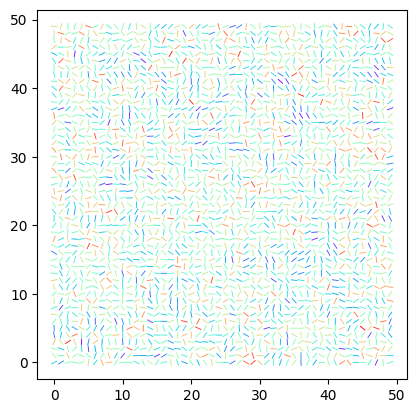

212: Size: 50, Steps: 10000, T*: 0.500: Order: 0.820, Time: 556.402434 s


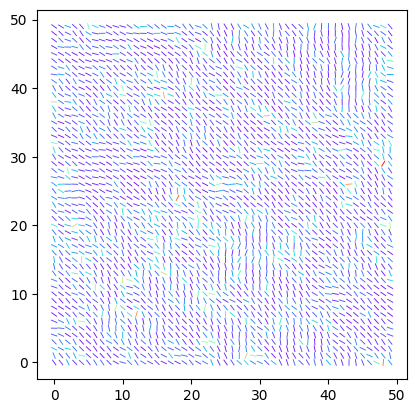

Time:556.7145659923553


In [49]:
start = time.time()
main(212, 10000, 50, 0.5, 1)
end = time.time()
print(f'Time:{end-start}')
# color_array according to energy

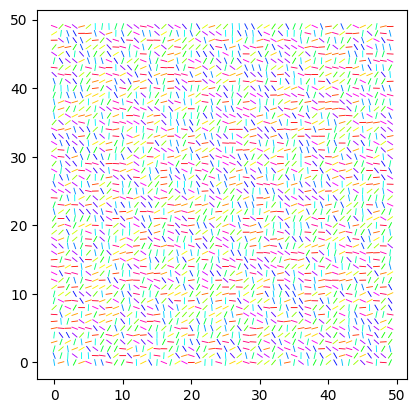

212: Size: 50, Steps: 50, T*: 0.500: Order: 0.290, Time: 4.354067 s


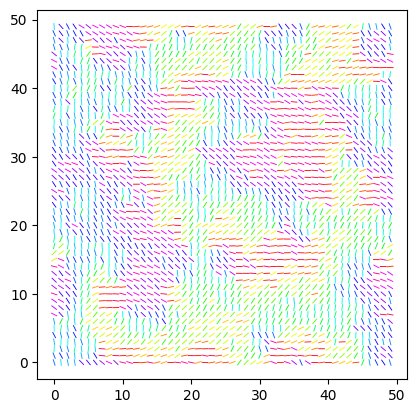

Time:4.656404256820679


In [19]:
start = time.time()
main(212, 50, 50, 0.5, 2)
end = time.time()
print(f'Time:{end-start}')

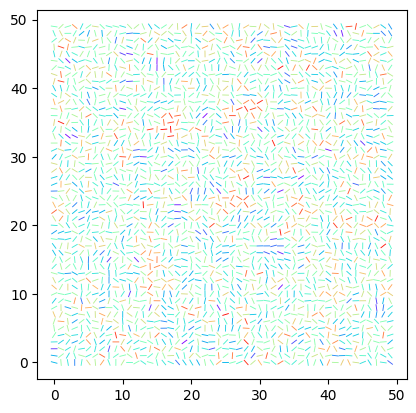

212: Size: 50, Steps: 50, T*: 0.500: Order: 0.307, Time: 2.654829 s


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [37]:
start = time.time()
main(212, 50, 50, 0.5, 1)
end = time.time()
print(f'Time:{end-start}')